In [ ]:
import os
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
directory = '/content/drive/MyDrive/Monkeypox Skin Image Dataset v6'

Mounted at /content/drive


##Data Exploration

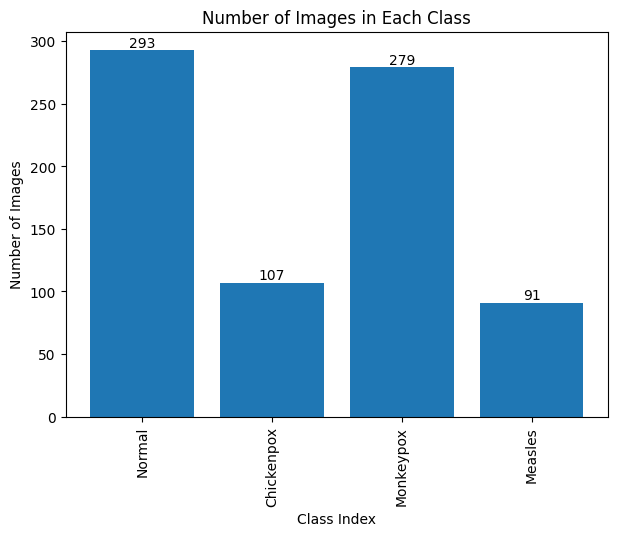

In [ ]:
import os
import matplotlib.pyplot as plt

def plot_dataset():
    class_names = os.listdir(directory)
    new_num_images = []
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        new_num_images.append(len(os.listdir(class_path)))

    plt.figure(figsize=(7, 5))
    plt.bar(range(len(class_names)), new_num_images)
    plt.title('Number of Images in Each Class')
    plt.xlabel('Class Index')
    plt.ylabel('Number of Images')
    plt.xticks(range(len(class_names)), class_names, rotation=90)

    for i, num_images in enumerate(new_num_images):
        plt.text(i, num_images, str(num_images), ha='center', va='bottom')

    plt.show()

plot_dataset()

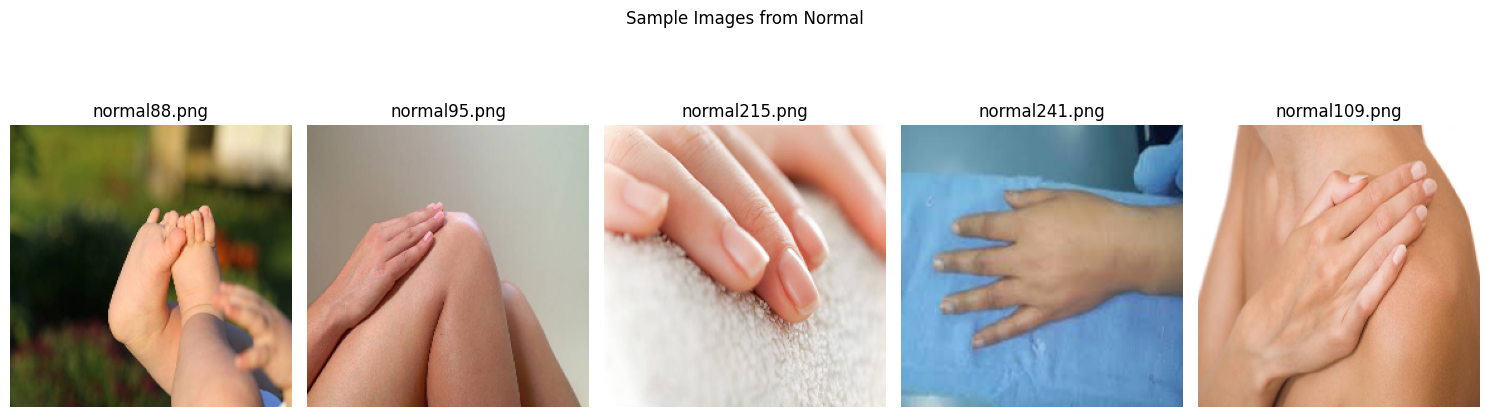

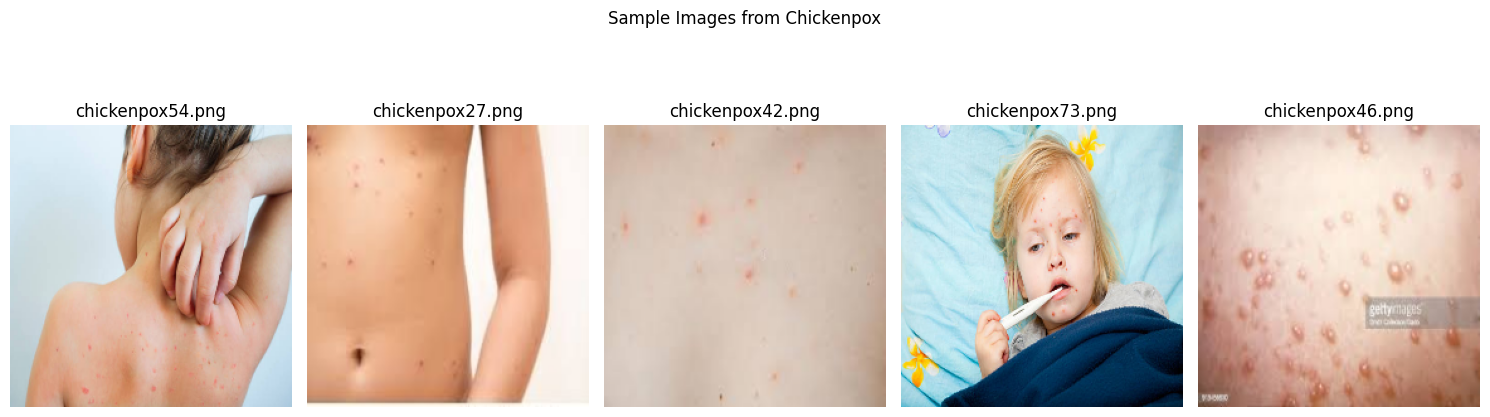

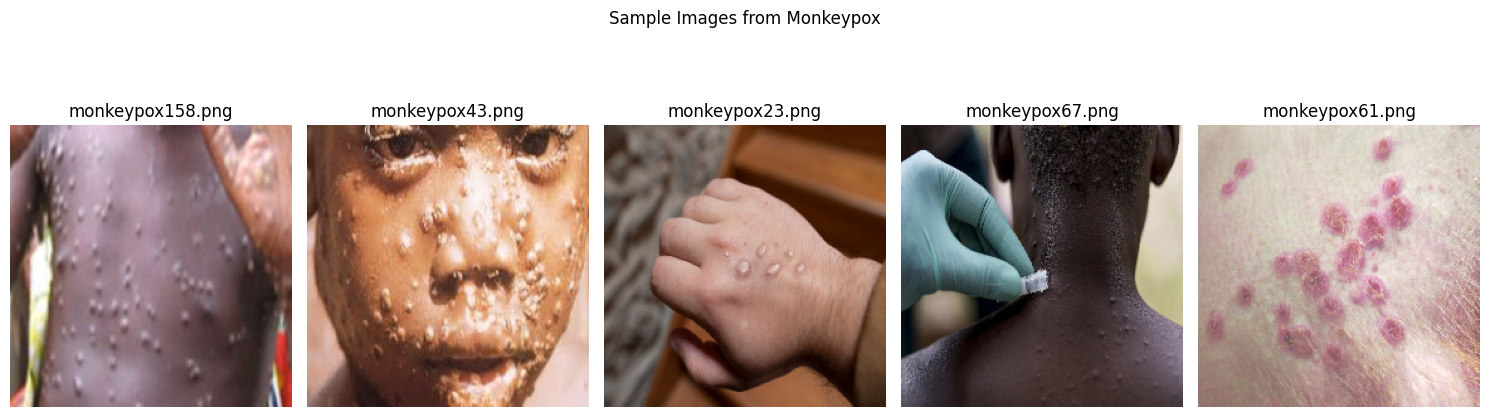

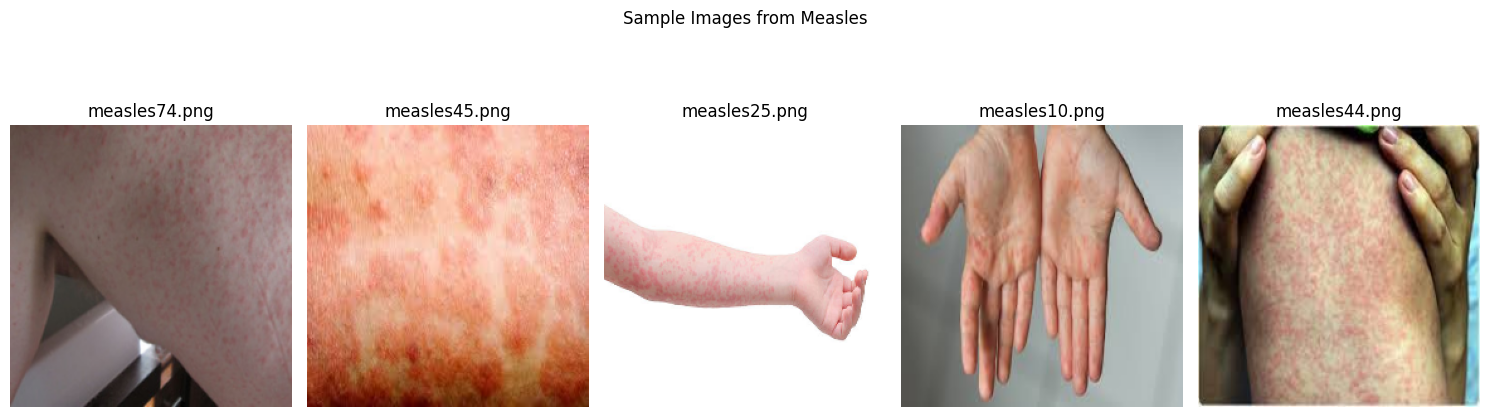

In [ ]:
import random
from PIL import Image, UnidentifiedImageError

def display_images():
    class_names = os.listdir(directory)
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        files = os.listdir(class_path)

        if files:
            sample_files = random.sample(files, min(5, len(files))) #choose 5 images
            plt.figure(figsize=(15,5))
            plt.suptitle(f'Sample Images from {class_name}')

            for i, file in enumerate(sample_files):
                file_path = os.path.join(class_path, file)
                try:
                    img = Image.open(file_path)
                    plt.subplot(1, len(sample_files), i + 1)
                    plt.imshow(img)
                    plt.title(file)
                    plt.axis('off')
                except UnidentifiedImageError:
                    print(f"File {file} not valid, skipped.")
                    continue

            plt.tight_layout()
            plt.show()

display_images()

##Preprocessing

In [ ]:
DATASET_DIR = directory
training_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2)

train_generator = training_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32,
    subset='training') #training data

val_generator = training_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32,
    subset='validation') #testing data

Found 618 images belonging to 4 classes.
Found 152 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2

pre_trained_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224, 3))

pre_trained_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
import numpy as np

x_train_list, y_train_list = [], []

for i in range(len(train_generator)):
    x_train_batch, y_train_batch = train_generator[i]
    x_train_list.append(x_train_batch)
    y_train_list.append(y_train_batch)

x_train = np.concatenate(x_train_list)
y_train = np.concatenate(y_train_list)

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)

x_train shape: (618, 224, 224, 3)
y_train shape: (618, 4)


##K Fold CV

In [ ]:
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=1)

acc_per_fold = []
loss_per_fold = []
val_acc_per_fold = []
val_loss_per_fold = []

fold_no = 1

for train_index, val_index in skf.split(x_train, y_train.argmax(1)):
    print(f'Training for fold {fold_no} ...')

    x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    print(f'Number of training samples: {x_train_fold.shape[0]}')
    print(f'Number of validation samples: {x_val_fold.shape[0]}')

    #training
    for layer in pre_trained_model.layers[:-4]:
        layer.trainable = False

    x = pre_trained_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(4, activation='softmax')(x)

    model = Model(
        inputs=pre_trained_model.input,
        outputs=predictions)

    if fold_no == 1:
        model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.0001), #ubah lr
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    # Melatih model
    history = model.fit(
        x_train_fold, y_train_fold,
        epochs=50,
        validation_data=(x_val_fold, y_val_fold), #data validasi
        verbose=1
    )

    # Evaluasi model
    #scores[0]: nilai loss, scores[1]: nilai akurasi
    scores = model.evaluate(x_val_fold, y_val_fold, verbose=0)
    print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]}')

    acc_per_fold.append(scores[1])
    loss_per_fold.append(scores[0])
    val_acc_per_fold.append(history.history['val_accuracy'])
    val_loss_per_fold.append(history.history['val_loss'])

    fold_no += 1

Training for fold 1 ...
Number of training samples: 494
Number of validation samples: 124


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 4,096,580 (15.63 MB)

 Trainable params: 2,251,396 (8.59 MB)

 Non-trainable params: 1,845,184 (7.04 MB)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3895 - loss: 1.4063 - val_accuracy: 0.6935 - val_loss: 0.8126
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.6846 - loss: 0.8249 - val_accuracy: 0.8065 - val_loss: 0.5787
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8058 - loss: 0.6259 - val_accuracy: 0.8468 - val_loss: 0.4779
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8251 - loss: 0.5147 - val_accuracy: 0.8548 - val_loss: 0.4314
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8949 - loss: 0.4047 - val_accuracy: 0.8629 - val_loss: 0.3802
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8769 - loss: 0.3604 - val_accuracy: 0.8790 - val_loss: 0.3518
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9388 - loss: 0.2382 - val_accuracy: 0.8871 - val_loss: 0.3297
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9398 - loss: 0.2154 - val_accuracy: 0.8952 - v

In [ ]:
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
    print('------------------------------------------------------------------------')
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')

for i, val_acc in enumerate(val_acc_per_fold):
    print(f'Validation accuracy for fold {i+1}: {val_acc * 100}%')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Loss: 0.3924669921398163 - Accuracy: 0.8790322542190552%
------------------------------------------------------------------------
> Fold 2 - Loss: 0.23264817893505096 - Accuracy: 0.8790322542190552%
------------------------------------------------------------------------
> Fold 3 - Loss: 0.09990055114030838 - Accuracy: 0.9677419066429138%
------------------------------------------------------------------------
> Fold 4 - Loss: 0.10554338246583939 - Accuracy: 0.9756097793579102%
------------------------------------------------------------------------
> Fold 5 - Loss: 0.0069715967401862144 - Accuracy: 1.0%
------------------------------------------------------------------------
Average scores for all folds:
> Accuracy: 0.9402832388877869 (+- 0.051130031683904224)
> Loss: 0.16750614028424024
Validation accuracy for fold

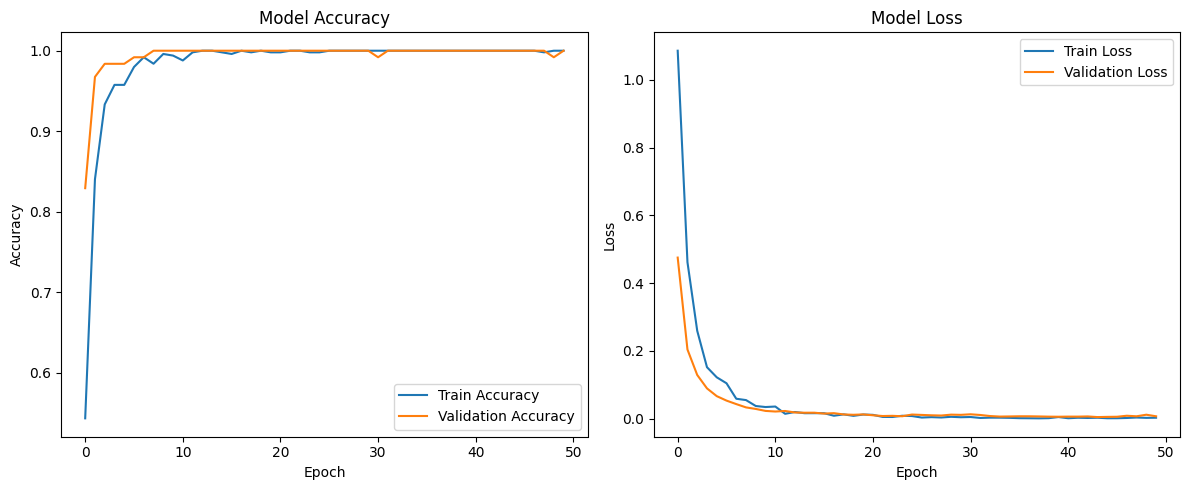

In [ ]:
# Plot akurasi dan loss
plt.figure(figsize=(12, 5))

# Plot akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Shape of x_val: (152, 224, 224, 3)
Shape of y_val: (152, 4)
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
Predicted Classes:  [3 3 2 3 2 2 2 3 1 3 3 3 3 2 2 0 2 3 2 1 3 2 0 0 2 3 3 2 3 3 3 0 0 1 3 3 0
 3 2 3 2 3 3 3 2 0 2 2 2 0 2 2 3 0 0 0 3 3 3 2 2 3 3 2 2 2 0 2 2 0 3 0 3 2
 3 3 1 1 3 3 0 3 2 2 2 2 3 3 2 1 2 1 3 0 1 2 3 0 2 2 3 1 1 3 2 2 2 3 3 1 2
 2 1 2 2 0 3 3 3 2 2 3 2 3 0 2 2 1 3 3 0 2 3 3 0 1 3 2 3 3 2 2 2 3 1 2 3 3
 2 2 1 3]
True Classes:  [3 3 2 3 2 0 2 3 1 3 3 3 3 2 2 0 2 3 2 0 3 2 0 0 2 3 3 2 3 3 3 0 0 1 3 3 0
 1 2 3 2 3 3 3 2 0 2 2 2 0 2 2 3 1 0 2 3 3 2 2 1 3 3 2 1 2 0 2 2 0 3 0 3 2
 3 3 1 1 3 3 0 3 2 2 2 2 3 3 2 1 2 1 3 0 1 2 3 2 2 2 3 1 1 3 3 2 3 3 3 2 2
 1 1 2 2 2 3 3 3 2 2 3 2 3 0 2 2 0 3 3 2 2 3 3 0 1 3 2 3 3 2 2 2 0 1 2 3 3
 2 0 1 3]


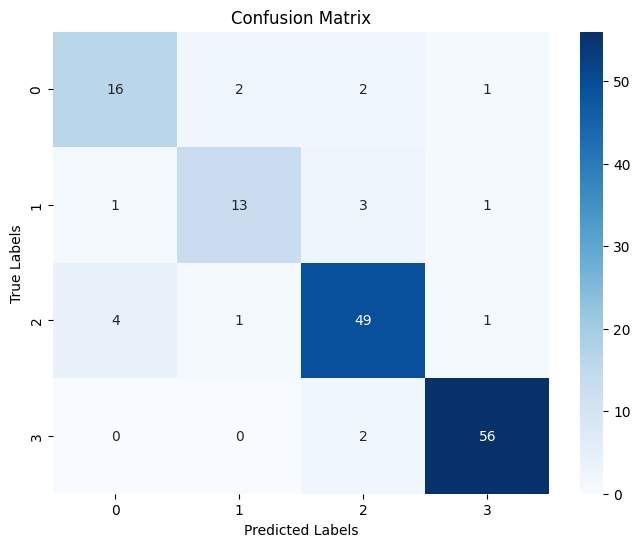

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76        21
           1       0.81      0.72      0.76        18
           2       0.88      0.89      0.88        55
           3       0.95      0.97      0.96        58

    accuracy                           0.88       152
   macro avg       0.85      0.84      0.84       152
weighted avg       0.88      0.88      0.88       152



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

x_val_list = []
y_val_list = []

for i in range(len(val_generator)):
    x_val_batch, y_val_batch = val_generator[i]
    x_val_list.append(x_val_batch)
    y_val_list.append(y_val_batch)

x_val = np.concatenate(x_val_list)
y_val = np.concatenate(y_val_list)

print("Shape of x_val:", x_val.shape)
print("Shape of y_val:", y_val.shape)

y_val_pred = model.predict(x_val)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
y_val_true_classes = np.argmax(y_val, axis=1)

print("Predicted Classes: ", y_val_pred_classes)
print("True Classes: ", y_val_true_classes)

conf_matrix = confusion_matrix(y_val_true_classes, y_val_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_val_true_classes, y_val_pred_classes))

In [ ]:
model.save("model-mobilenetv2.h5")